In [1]:
import numpy as np
from IQAEBinom_FinalRoundNShotFixed import IQAEBinom_FinalRoundNShotFixed
import matplotlib.pyplot as plt
import pickle
from BiasCorrection import BiasCoxSnell, BiasExact
import datetime
import pandas as pd

In [2]:
epsilon = 0.001
nEstim = 100000
alpha = 0.05
nShotUnit = 100
nShotFinal = 100

In [3]:
pTrue = 0.2505
results = np.array([])

for i in range(nEstim):
    if i % 1000 == 0:
        print(i)
    result = IQAEBinom_FinalRoundNShotFixed(pTrue, epsilon, alpha, nShotUnit, nShotFinal, confint_method="chernoff")
    results = np.append(results, result)

# resFileName = "C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/results_IQAE_pTrue" + str(pTrue) + "_epsilon0001_alpha005_nShotUnit50.dat"
# with open(resFileName, 'wb') as f:
#     pickle.dump(results, f) 
biases = [BiasCoxSnell(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]    
print(np.mean(biases))
errs = np.array([r["Estimate"] - pTrue for r in results])
print(np.mean(errs))

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
-5.776850097810925e-08
-3.0333322607073652e-06


In [4]:
print(np.std(errs) / np.sqrt(nEstim))

5.061329606088667e-07


なぜかbias dominated...

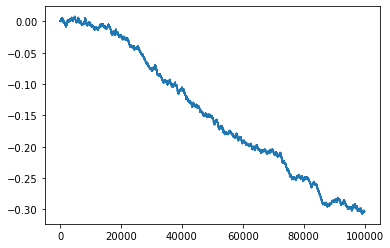

In [5]:
ax = plt.gca()
plt.plot(np.array(errs).cumsum())
plt.show()

In [6]:
results[0]

{'Estimate': 0.2505276407335732,
 'TotalOracleCalls': 60500,
 'nGrover': [0, 2, 6, 23, 60, 198],
 'nShots': [400, 200, 200, 100, 100, 100],
 'n1s': [89, 49, 48, 20, 30, 48],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.3324698111225186, 0.6209250367554824],
  [0.4921399638414686, 0.5660830214234738],
  [0.5076666117214415, 0.5346640139617587],
  [0.5204782191034113, 0.5322050771012905],
  [0.5222866999502048, 0.5255366372915147],
  [0.5238091118211405, 0.524601343642632]],
 'ampSqIntervals': [[0, 1],
  [0.10652297983041131, 0.33847702016958875],
  [0.22326850638471038, 0.28765009348994286],
  [0.2363315822866858, 0.25964321258533724],
  [0.24730240526634206, 0.25748994100317224],
  [0.2488645712319377, 0.2516801109054371],
  [0.2501821786276074, 0.25086875138477877]]}

In [7]:
np.unique([r["nShots"][-1] for r in results])

array([100])

(array([3.000e+00, 8.300e+01, 3.105e+03, 7.460e+03, 5.519e+03, 7.048e+03,
        7.884e+03, 6.148e+03, 5.595e+03, 5.859e+03, 5.115e+03, 4.370e+03,
        4.805e+03, 3.678e+03, 3.719e+03, 4.481e+03, 3.050e+03, 2.397e+03,
        3.789e+03, 2.401e+03, 1.995e+03, 2.610e+03, 1.623e+03, 1.572e+03]),
 array([ 60.,  70.,  80.,  90., 100., 110., 120., 130., 140., 150., 160.,
        170., 180., 190., 200., 210., 220., 230., 240., 250., 260., 270.,
        280., 290., 300.]),
 <BarContainer object of 24 artists>)

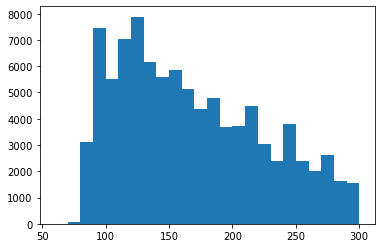

In [10]:
plt.hist([r["nGrover"][-1] for r in results], range=(60, 300), bins = 24)

In [12]:
biasesExact = [BiasExact(pTrue, r["nGrover"][-1], r["nShots"][-1]) for r in results]   

In [14]:
print(np.mean(biasesExact))
print(np.std(biasesExact) / np.sqrt(nEstim))

-5.525533521584371e-09
1.2389238375466044e-08


OnlyFinalRoundのbiasとBiasExactは良く合っている

In [15]:
from IQAEBinom_OnlyFinalRound import IQAEBinom_OnlyFinalRound

In [17]:
nGs = [r["nGrover"][-1] for r in results]
nGUnique, cntnG = np.unique(nGs, return_counts=True)
print(len(nGUnique))
errMean_onlyFinal = np.array([])
biasExact_OnlyFinal = np.array([])
for nG in nGUnique:
    print(nG)
    estims = np.array([])
    for _ in range(100000):
        estim = IQAEBinom_OnlyFinalRound(pTrue, nG, 100)
        estims = np.append(estims, estim)
    errMean_onlyFinal = np.append(errMean_onlyFinal, np.mean(estims - pTrue))
    biasExact_OnlyFinal = np.append(biasExact_OnlyFinal, BiasExact(pTrue, nG, 100))

284
66
69
71
74
75
77
78
80
81
83
84
86
87
89
90
92
93
95
96
98
99
101
102
104
105
107
108
110
111
113
114
116
117
119
120
121
122
123
124
125
126
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
155
156
158
159
160
161
162
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
230
231
232
233
234
236
237
238
239
240
241
242
243
244
245
246
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
311
312
313
315
316
318
319
320
321
323
324
325
327
328
329
330
331
332
333
334
336
337
338
339
340
341
342
343
344
345
348
349
351
352
354
355
356
357
361
3

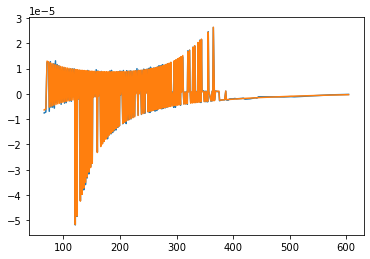

In [29]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact")
plt.show()

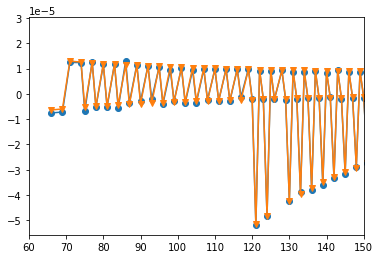

In [21]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact", marker="v")
ax.set_xlim(60, 150)
plt.show()

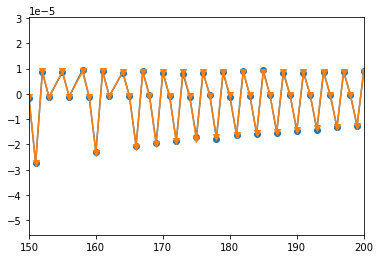

In [22]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact", marker="v")
ax.set_xlim(150, 200)
plt.show()

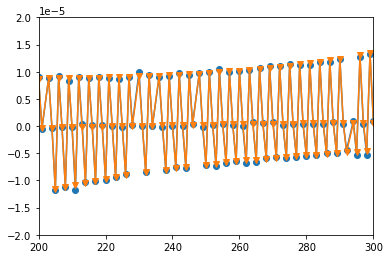

In [24]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact", marker="v")
ax.set_xlim(200, 300)
ax.set_ylim(-2e-5, 2e-5)
plt.show()

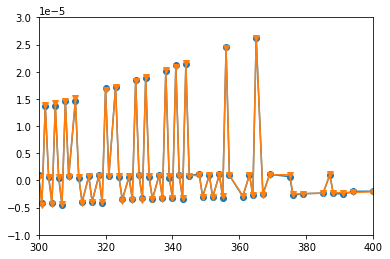

In [26]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact", marker="v")
ax.set_xlim(300, 400)
ax.set_ylim(-1e-5, 3e-5)
plt.show()

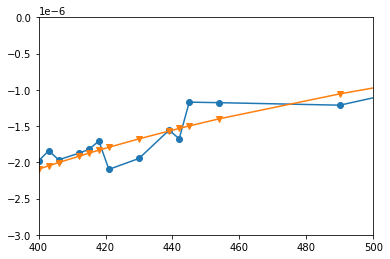

In [28]:
ax = plt.gca()
plt.plot(nGUnique, errMean_onlyFinal, label="ErrMean", marker="o")
plt.plot(nGUnique, biasExact_OnlyFinal, label="BiasExact", marker="v")
ax.set_xlim(400, 500)
ax.set_ylim(-3e-6, 0)
plt.show()

各nGroverに対するOnlyFinalの平均誤差の加重和を取っても、実験結果の平均誤差と一致せず（後者がでかすぎ）

In [31]:
np.dot(cntnG, errMean_onlyFinal)

-0.000994688078901846

In [32]:
np.dot(cntnG, errMean_onlyFinal) / nEstim

-9.94688078901846e-09

(array([2.700e+01, 2.400e+01, 2.500e+01, 2.200e+01, 1.600e+01, 1.400e+01,
        1.100e+01, 4.000e+00, 5.000e+00, 3.000e+00, 7.000e+00, 5.000e+00,
        2.000e+00, 1.000e+01, 7.000e+00, 7.000e+00, 1.100e+01, 1.400e+01,
        8.000e+00, 3.300e+01, 1.700e+01, 9.000e+00, 1.080e+02, 8.000e+00,
        1.850e+02, 0.000e+00, 2.700e+01, 2.340e+02, 7.300e+01, 1.630e+02,
        2.640e+02, 2.380e+02, 3.970e+02, 4.640e+02, 5.170e+02, 7.470e+02,
        7.960e+02, 1.120e+03, 1.039e+03, 1.385e+03, 2.058e+03, 2.205e+03,
        2.819e+03, 3.005e+03, 4.135e+03, 4.232e+03, 5.100e+03, 5.959e+03,
        6.066e+03, 6.200e+03, 6.582e+03, 6.094e+03, 5.588e+03, 5.438e+03,
        4.434e+03, 3.833e+03, 3.360e+03, 2.650e+03, 2.093e+03, 1.874e+03,
        1.299e+03, 1.242e+03, 1.167e+03, 8.480e+02, 7.310e+02, 4.930e+02,
        4.460e+02, 3.650e+02, 3.250e+02, 2.520e+02, 1.790e+02, 1.630e+02,
        8.900e+01, 1.100e+02, 9.700e+01, 5.600e+01, 5.200e+01, 3.500e+01,
        3.500e+01, 2.400e+01, 1.700e+0

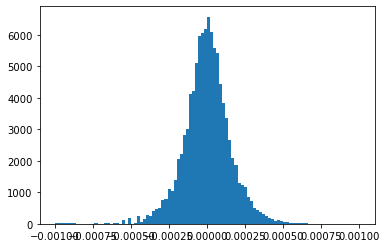

In [34]:
plt.hist(errs, range=(-1e-3, 1e-3), bins=100)

In [36]:
df = pd.DataFrame({"nGrov": nGUnique, "cnt":cntnG}).sort_values('cnt', ascending=False)
print(df)

     nGrov   cnt
28     111  2963
37     123  2543
22     102  2328
16      93  2247
34     120  1971
..     ...   ...
38     124     1
35     121     1
4       75     1
2       71     1
283    604     1

[284 rows x 2 columns]


In [41]:
nGTop10 = df["nGrov"][:10]
print(nGTop10)

28     111
37     123
22     102
16      93
34     120
48     135
68     156
30     114
45     132
111    201
Name: nGrov, dtype: int32


In [45]:
errs_nGTop10 = errs[[np.isin(r["nGrover"][-1], nGTop10) for r in results]]
print(len(errs_nGTop10))
print(np.mean(errs_nGTop10))
print(np.std(errs_nGTop10) / np.sqrt(len(errs_nGTop10)))

20975
-3.4829039250183013e-06
1.2587349369852395e-06


In [53]:
for nG in nGTop10:
    errs_specnG = errs[[r["nGrover"][-1]==nG for r in results]]
    print(nG, np.mean(errs_specnG), np.std(errs_specnG) / np.sqrt(len(errs_specnG)), BiasExact(pTrue, nG, 100))

111 -3.7790179329411607e-06 3.534274229693817e-06 -2.6706207959206474e-06
123 -4.8342023658925205e-06 3.4162009219106988e-06 -2.148960986648197e-06
102 -7.071902161486417e-06 4.361726575435923e-06 -3.1449525334325544e-06
93 -1.1035536623361063e-05 4.944080740787383e-06 -3.713567603487381e-06
120 -3.1317830541024994e-06 4.070269346381116e-06 -2.269297438363815e-06
135 -2.2025276673163636e-06 3.818540828077609e-06 -1.7227552348601898e-06
156 -4.85350863309261e-06 3.289053986151418e-06 -1.1395862348920382e-06
114 2.1578043628030582e-06 4.462725934827722e-06 -2.529592749201859e-06
132 3.4140709374043096e-06 4.000442729115938e-06 -1.8217963753067387e-06
201 4.829615986943393e-07 2.714421418492003e-06 -3.1176149623349586e-07


In [56]:
biasExact = np.array([BiasExact(pTrue, r["nGrover"][-1], 100) for r in results])
biasExact_nGTop10 = biasExact[[np.isin(r["nGrover"][-1], nGTop10) for r in results]]
np.mean(biasExact_nGTop10)

-2.243206068448226e-06

In [58]:
biasExact_notnGTop10 = biasExact[[not(np.isin(r["nGrover"][-1], nGTop10)) for r in results]]
np.mean(biasExact_notnGTop10)

5.884048583808049e-07

In [52]:
thetaTrue = np.arcsin(np.sqrt(pTrue))
np.sin((2 * nGTop10 + 1) * thetaTrue) ** 2

28     0.368473
37     0.381886
22     0.358479
16     0.348546
34     0.378524
48     0.395389
68     0.419207
30     0.371817
45     0.392005
111    0.470812
Name: nGrov, dtype: float64

実現数の少ないnGroverが悪さしてるのかなあ...

final roundでのtrue p1で集計してみる

In [9]:
trueP1Final = np.array([np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 for r in results])

In [28]:
trueP1Final_percentile = np.percentile(trueP1Final, np.linspace(0, 100, 101, endpoint=True))
print(trueP1Final_percentile)

[0.01030652 0.07365604 0.09075553 0.10304264 0.10944459 0.1182423
 0.12503323 0.13198603 0.1390977  0.14636517 0.15129516 0.15881529
 0.16907068 0.33867904 0.34196064 0.34524982 0.34524982 0.34854642
 0.34854642 0.35185028 0.35516126 0.35516126 0.35847918 0.35847918
 0.36180388 0.36513522 0.36847303 0.36847303 0.36847303 0.37181714
 0.37181714 0.37516741 0.37852366 0.37852366 0.38188574 0.38188574
 0.38525348 0.38862673 0.38862673 0.39200532 0.39538909 0.39538909
 0.39877788 0.39877788 0.40217152 0.40556986 0.40556986 0.40897273
 0.41237996 0.4157914  0.4157914  0.41920687 0.41920687 0.42262622
 0.42604929 0.4294759  0.43290589 0.43290589 0.43977536 0.43977536
 0.44321452 0.44665639 0.45010083 0.45354766 0.45699672 0.46044784
 0.46044784 0.4673556  0.47081192 0.47081192 0.47426964 0.47772858
 0.4811886  0.48464952 0.48811118 0.49157341 0.49503604 0.49849891
 0.50196185 0.50542469 0.51234944 0.51581101 0.51927182 0.51927182
 0.5261905  0.52964804 0.53655868 0.54346231 0.54691109 0.55035

In [30]:
errMeanSpecTP1 = np.array([])
for i in range(len(trueP1Final_percentile)-1):
    errs_specTP1 = errs[(trueP1Final_percentile[i]<=trueP1Final) & (trueP1Final<trueP1Final_percentile[i+1])]
    errMeanSpecTP1 = np.append(errMeanSpecTP1, np.mean(errs_specTP1))

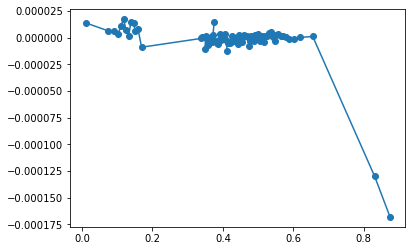

In [31]:
ax = plt.gca()
plt.plot(trueP1Final_percentile[:-1], errMeanSpecTP1, marker="o")
plt.show()

In [32]:
results_finalTrueP1Gt085 = results[trueP1Final >= 0.85]

In [33]:
len(results_finalTrueP1Gt085)

1570

(array([  0.,   1.,   4.,  20.,  73.,  71.,  24.,   7.,   0.,   5.,   0.,
          2.,  19., 135., 547., 544., 109.,   9.]),
 array([-1.50000000e-03, -1.40000000e-03, -1.30000000e-03, -1.20000000e-03,
        -1.10000000e-03, -1.00000000e-03, -9.00000000e-04, -8.00000000e-04,
        -7.00000000e-04, -6.00000000e-04, -5.00000000e-04, -4.00000000e-04,
        -3.00000000e-04, -2.00000000e-04, -1.00000000e-04, -2.16840434e-19,
         1.00000000e-04,  2.00000000e-04,  3.00000000e-04]),
 <BarContainer object of 18 artists>)

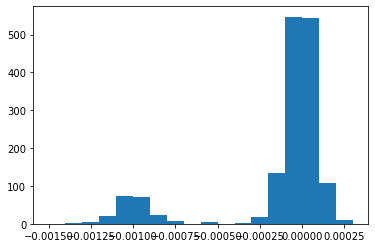

In [41]:
errs_finalTrueP1Gt085 = errs[trueP1Final >= 0.85]
plt.hist(errs_finalTrueP1Gt085, range=(-0.0015, 0.0003), bins=18)

In [42]:
results_finalTrueP1Gt085_UndEstim = results_finalTrueP1Gt085[errs_finalTrueP1Gt085 <= -5e-4]

In [43]:
results_finalTrueP1Gt085_UndEstim[0]

{'Estimate': 0.24971360611201693,
 'TotalOracleCalls': 81500,
 'nGrover': [0, 2, 5, 11, 27, 71, 214],
 'nShots': [600, 100, 100, 100, 100, 200, 100],
 'n1s': [150, 35, 28, 25, 25, 24, 98],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.4050750698862091, 0.6274806418176342],
  [0.45842277745358595, 0.5527512988541886],
  [0.5012097156807999, 0.5458908601795394],
  [0.514601115081243, 0.5360960345376377],
  [0.5188117132346561, 0.5271507635750632],
  [0.5236768687573748, 0.5272603054975876],
  [0.5225979809223381, 0.5235987755982988]],
 'ampSqIntervals': [[0, 1],
  [0.1553051595653449, 0.34469484043465504],
  [0.19583659000196532, 0.2756573382552002],
  [0.23086757740258726, 0.26954754379965945],
  [0.24224869582604147, 0.26089990353389386],
  [0.2458658036142243, 0.25308239423122403],
  [0.2500676337086173, 0.2531776529384407],
  [0.24913378776019793, 0.24999999999999994]]}

In [44]:
trueP1Final_finalTrueP1Gt085 = trueP1Final[trueP1Final >= 0.85]
trueP1Final_finalTrueP1Gt085_UndEstim = trueP1Final_finalTrueP1Gt085[errs_finalTrueP1Gt085 <= -5e-4]

(array([29.,  0., 65.,  0.,  8.,  9., 41., 16., 29.,  8.]),
 array([0.85085013, 0.86340914, 0.87596815, 0.88852715, 0.90108616,
        0.91364517, 0.92620417, 0.93876318, 0.95132219, 0.96388119,
        0.9764402 ]),
 <BarContainer object of 10 artists>)

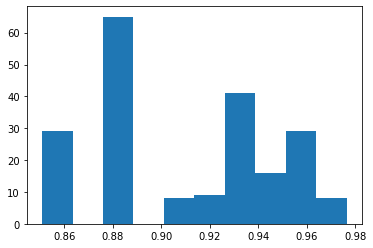

In [45]:
plt.hist(trueP1Final_finalTrueP1Gt085_UndEstim)

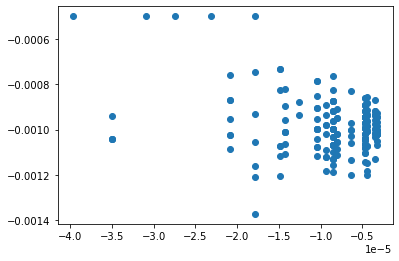

In [52]:
errs_finalTrueP1Gt085_UndEstim = errs_finalTrueP1Gt085[errs_finalTrueP1Gt085 <= -5e-4]
biasesExact_finalTrueP1Gt085_UndEstim = [BiasExact(pTrue, r["nGrover"][-1], 100) for r in results_finalTrueP1Gt085_UndEstim]
plt.scatter(biasesExact_finalTrueP1Gt085_UndEstim, errs_finalTrueP1Gt085_UndEstim)

In [ ]:
from BiasCorrection import ErrorDistribution

In [58]:
errors_nG214_nShot100, probs_nG214_nShot100 = ErrorDistribution(pTrue, 214, 100)

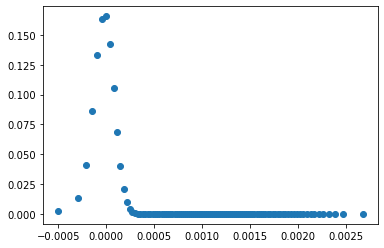

In [59]:
plt.scatter(errors_nG214_nShot100, probs_nG214_nShot100)

In [63]:
results2 = np.array([])

for i in range(nEstim):
    if i % 1000 == 0:
        print(i)
    result = IQAEBinom_FinalRoundNShotFixed(pTrue, epsilon, alpha, nShotUnit, nShotFinal, confint_method="chernoff")
    results2 = np.append(results2, result)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000


In [68]:
results2_finalTrueP1Gt085_UndEstim = results2[[(r["Estimate"] - pTrue < -5e-4) & (np.sin((2 * r["nGrover"][-1] + 1) * thetaTrue) ** 2 >= 0.85) for r in results2]]

In [70]:
results2_finalTrueP1Gt085_UndEstim[0]

{'Estimate': 0.24954489270546334,
 'TotalOracleCalls': 123900,
 'nGrover': [0, 2, 6, 26, 71, 214, 214],
 'nShots': [600, 200, 200, 100, 200, 100, 100],
 'n1s': [148, 35, 43, 29, 22, 88, 95],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.40045310539241963, 0.6239697967382674],
  [0.506728427954071, 0.5973756983469892],
  [0.5041978571712368, 0.5326728823425617],
  [0.5191450668457906, 0.5272289203828832],
  [0.523759290256271, 0.5272603054975876],
  [0.5235987755982988, 0.524881036450704],
  [0.5225084779466764, 0.5235987755982988]],
 'ampSqIntervals': [[0, 1],
  [0.15197182623201158, 0.3413615071013218],
  [0.2355349131430633, 0.31637767781511594],
  [0.23339070172960316, 0.257899144169861],
  [0.2461529437783876, 0.2531503589303664],
  [0.25013902265157356, 0.2531776529384407],
  [0.24999999999999994, 0.2511112913512394],
  [0.24905636965855535, 0.24999999999999994]]}

In [72]:
resSamp = results2_finalTrueP1Gt085_UndEstim[0]
rRounds = [int((2 * resSamp["nGrover"][i] + 1) * resSamp["thetaIntervals"][i][0] / (0.5 * np.pi)) for i in range(len(resSamp["nGrover"]))]
print(rRounds)

[0, 1, 4, 17, 47, 143, 142]
